# Jigsaw Puzzle Reconstruction

Reconstruction of a 96×96 RGB image from 9 scrambled 28×28 patches taken from a 3×3 partition of the original image. The arrangement of the patches is unknown and part of the border information has been removed by erosion, so the model must infer both the correct placement of the patches and the missing content.

**Approach.** A single end-to-end neural pipeline: a siamese convolutional encoder embeds each patch, a Transformer reasons jointly over the 9 patch tokens, and an attention mechanism learns to assign each patch to its grid position. A convolutional decoder reconstructs the full image. The placement is learned implicitly as a continuous attention matrix, never given to the network.

**Constraints satisfied:** entirely neural (no hand-crafted algorithms), no pretrained models, **3,246,083 trainable parameters** (< 6M, reported by `model.summary()`), weights downloadable via `gdown` (verified in the last cell), reconstruction measured with **MAE** (mean and std on the test set).

## 1. Setup and configuration
Imports, random seeds for reproducibility, and the main hyperparameters. With `TRAIN_FROM_SCRATCH = True` the model is trained from scratch; with `False` the weights are downloaded via gdown and evaluated instead.

In [ ]:
# =========================
# 1. Setup Colab
# =========================

from google.colab import drive
drive.mount('/content/drive')

import os
import random
import numpy as np
import tensorflow as tf
import keras
from keras import layers, models
from keras.utils import PyDataset
import matplotlib.pyplot as plt

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)
print('GPU disponibili:', tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# True: prova tecnica rapida
# False: training
FAST_DEBUG = False

# True: allena da zero.
# False: scarica i pesi con gdown e fa direttamente valutazione/figure.
TRAIN_FROM_SCRATCH = True


WEIGHTS_FILE_ID = '13Ge6MB-6Gbe5k3zDZOLSsB878sHmrUhS'



BATCH_SIZE = 16 if FAST_DEBUG else 32
EPOCHS = 2 if FAST_DEBUG else 40
EARLY_STOP_PATIENCE = 1 if FAST_DEBUG else 7
LEARNING_RATE = 3e-4

# Priorità: MAE puro. Niente edge loss.
USE_EDGE_AUXILIARY_LOSS = False
EDGE_LOSS_WEIGHT = 0.0

WORK_DIR = '/content/drive/MyDrive/jigsaw_patch_reconstruction_attention'
os.makedirs(WORK_DIR, exist_ok=True)

BEST_WEIGHTS_PATH = os.path.join(WORK_DIR, 'best_jigsaw_idea1.weights.h5')
FINAL_WEIGHTS_PATH = os.path.join(WORK_DIR, 'final_jigsaw_attention.weights.h5')
DOWNLOADED_WEIGHTS_PATH = '/content/downloaded_best_jigsaw_attention.weights.h5'

print('Cartella pesi:', WORK_DIR)
print('Batch size:', BATCH_SIZE)
print('Epoche massime:', EPOCHS)
print('Train from scratch:', TRAIN_FROM_SCRATCH)


Mounted at /content/drive
TensorFlow: 2.20.0
Keras: 3.13.2
GPU disponibili: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Cartella pesi: /content/drive/MyDrive/jigsaw_patch_reconstruction_attention
Batch size: 32
Epoche massime: 40
Train from scratch: True


## 2. Dataset

The **STL-10** dataset is used (100K unlabeled color images, 96×96×3, covering 10 object classes). To avoid re-downloading on every run, the binary file is cached locally and reloaded if already present. The images are stored as `uint8` and converted to `float32` in [0, 1] only at batch time (inside the generator) rather than all at once: this keeps memory usage low and is what allows the full 100K set to be handled without exhausting RAM. The data is split into train / validation / test subsets, used respectively to fit the model, monitor generalisation during training, and report the final metric.

In [ ]:
# =========================
# 2.STL-10 Loader
# =========================

def download_and_load_stl10_memmap():
    path = tf.keras.utils.get_file(
        'stl10_binary.tar.gz',
        origin='http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz',
        extract=True,
    )

    base_dir = os.path.dirname(path)
    candidates = [
        os.path.join(base_dir, 'stl10_binary_extracted', 'stl10_binary', 'unlabeled_X.bin'),
        os.path.join(base_dir, 'stl10_binary', 'unlabeled_X.bin'),
    ]
    filepath = next((candidate for candidate in candidates if os.path.exists(candidate)), None)

    if filepath is None:
        raise FileNotFoundError(f'File unlabeled_X.bin non trovato. Percorsi provati: {candidates}')

    print('Loading memmap from:', filepath)

    raw = np.memmap(filepath, dtype=np.uint8, mode='r')
    n_images = raw.size // (3 * 96 * 96)
    images = raw.reshape(n_images, 3, 96, 96)

    # Same orientation used in the assignment notebook.
    images = np.transpose(images, (0, 3, 2, 1))
    return images


images = download_and_load_stl10_memmap()
print('Dataset shape:', images.shape)
print('Dataset dtype:', images.dtype)

train_images = images[:80000]
val_images = images[80000:90000]
test_images = images[90000:]



print('Train:', train_images.shape)
print('Val:', val_images.shape)
print('Test:', test_images.shape)


2640397119/2640397119 ━━━━━━━━━━━━━━━━━━━━ 281s 0us/step
Loading memmap from: /root/.keras/datasets/stl10_binary_extracted/stl10_binary/unlabeled_X.bin
Dataset shape: (100000, 96, 96, 3)
Dataset dtype: uint8
Train: (80000, 96, 96, 3)
Val: (10000, 96, 96, 3)
Test: (10000, 96, 96, 3)


## 3. Patch generator

The training samples are produced on the fly by a Keras `PyDataset`. For each source image the generator:
1. partitions it into a 3×3 grid and extracts the 9 patches (each cropped to 28×28 after the erosion of the borders, which removes part of the edge information);
2. randomly permutes the order of the 9 patches, so their spatial arrangement is unknown to the model;
3. returns the pair **(scrambled patches, original 96×96 image)** — the patches are the input `X`, the intact image is the target `Y`.

The random permutation is used only to shuffle the patches and is never returned or used as a label: the network receives only the scrambled patches and must infer the arrangement on its own. Normalisation to float [0, 1] is applied here, per batch, for memory efficiency. The batch size is 32.

In [ ]:
# =========================
# 3. Generator
# =========================

class PatchGenerator(PyDataset):
    def __init__(self, images, batch_size=32, patch_size=32, crop_size=28, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.images = images
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype='float32')
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype='float32')

        # RAM fix: normalize only the current batch, not the whole 100k-image dataset.
        batch_images = np.asarray(self.images[batch_indices], dtype='float32') / 255.0
        margin = (self.patch_size - self.crop_size) // 2

        for i, full_img in enumerate(batch_images):
            Y[i] = full_img
            patches = []

            for r in range(3):
                for c in range(3):
                    y_start = r * self.patch_size
                    x_start = c * self.patch_size
                    patch = full_img[
                        y_start : y_start + self.patch_size,
                        x_start : x_start + self.patch_size,
                        :,
                    ]
                    patch = patch[
                        margin : margin + self.crop_size,
                        margin : margin + self.crop_size,
                        :,
                    ]
                    patches.append(patch)

            # Same assignment logic as the provided generator:
            # every image is split into 9 patches and the patch order is randomized.
            order = np.random.permutation(9)

            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]

        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


train_generator = PatchGenerator(train_images, batch_size=BATCH_SIZE, shuffle=True)
val_generator = PatchGenerator(val_images, batch_size=BATCH_SIZE, shuffle=False)
test_generator = PatchGenerator(test_images, batch_size=BATCH_SIZE, shuffle=False)

x_batch, y_batch = train_generator[0]
print('Input batch:', x_batch.shape)
print('Target batch:', y_batch.shape)


Input batch: (32, 9, 28, 28, 3)
Target batch: (32, 96, 96, 3)


## 4. Visual inspection

A sanity check on the generator output: for a random sample, the 9 scrambled patches are displayed on a canvas (input) next to the corresponding original image (target). This confirms that the patches are extracted, eroded and shuffled correctly, and that input and target are aligned before training.

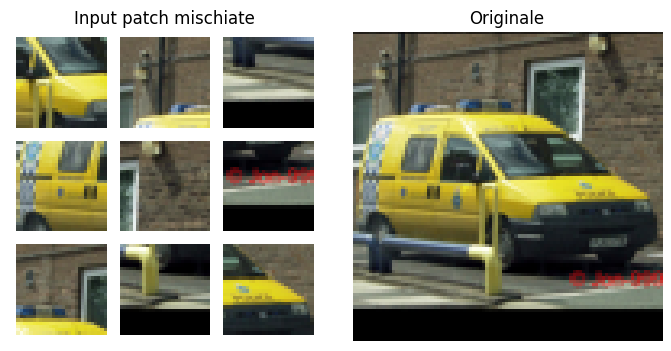

In [ ]:
# =========================
# 4. Visualize samples
# =========================

def scrambled_canvas(patches):
    canvas = np.ones((96, 96, 3), dtype=np.float32)
    margin = 2
    for i in range(9):
        r, c = divmod(i, 3)
        y0 = r * 32 + margin
        x0 = c * 32 + margin
        canvas[y0:y0 + 28, x0:x0 + 28] = patches[i]
    return canvas


def show_input_example(generator, batch_index=0):
    x, y = generator[batch_index]
    k = np.random.randint(0, x.shape[0])

    fig, ax = plt.subplots(1, 2, figsize=(7, 3.5))
    ax[0].imshow(scrambled_canvas(x[k]))
    ax[0].set_title('Input patch mischiate')
    ax[0].axis('off')

    ax[1].imshow(y[k])
    ax[1].set_title('Originale')
    ax[1].axis('off')
    plt.tight_layout()
    plt.show()


show_input_example(test_generator)


## 5. Model architecture

The whole solution is a single end-to-end neural network, organised in four stages.

**1. Siamese patch encoder.** A convolutional encoder (three conv stages, 32→64→96 filters, with two max-poolings) is applied to each of the 9 patches through `TimeDistributed`, so the **weights are shared** across patches: every patch is embedded by the same function regardless of its position. Each patch yields both a spatial feature map (kept for the decoder) and, via global average pooling and a dense projection, a compact **token** of dimension 160.

**2. Transformer over the patch tokens.** The 9 tokens pass through **six Transformer blocks** (multi-head self-attention and feed-forward, with residual connections and layer normalisation). This lets the patches "look at each other", so the representation of each patch is informed by the content of the others — essential to reason about how they fit together.

**3. Learned placement via attention.** Nine trainable **slot queries**, one per grid position, attend over the patch tokens. From this a continuous **attention matrix** is computed (a softmax over the 9 patches for each of the 9 slots): it acts as a soft assignment of patches to grid positions, **learned end-to-end** and produced entirely inside the network — it is never provided as input nor supervised. This same attention matrix is then used to reorder *both* the deep feature maps and the *raw RGB patches* into a 3×3 spatial grid.

**4. Convolutional decoder.** The reordered feature grid is processed by convolutional blocks and progressively upsampled towards 96×96. A **skip connection** injects the reordered raw RGB patches into the decoder, so the actual pixel content of the patches can be reused instead of being regenerated from scratch; this both lowers the reconstruction error and reduces blur. A final 1×1 convolution with sigmoid produces the RGB output in [0, 1].

The model has **3,246,083 trainable parameters**, well below the 6M limit (see the `model.summary()` output).

In [ ]:
# =========================
# 5. Transformer/attention model
# =========================

class PatchGridAttention(layers.Layer):
    def __init__(self, embed_dim=160, num_heads=4, temperature=0.7, **kwargs):  # embed_dim 128 -> 160
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.temperature = temperature
        self.slot_attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=0.05,
        )
        self.slot_norm = layers.LayerNormalization(epsilon=1e-6)
        self.slot_proj = layers.Dense(embed_dim, use_bias=False)
        self.patch_proj = layers.Dense(embed_dim, use_bias=False)

    def build(self, input_shape):
        self.slot_queries = self.add_weight(
            name='slot_queries',
            shape=(9, self.embed_dim),
            initializer='glorot_uniform',
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs, training=None):
        patch_maps, patch_tokens, patch_rgb = inputs
        batch_size = tf.shape(patch_tokens)[0]

        slot_queries = tf.tile(self.slot_queries[None, :, :], [batch_size, 1, 1])
        slot_context = self.slot_attention(
            query=slot_queries,
            key=patch_tokens,
            value=patch_tokens,
            training=training,
        )
        slot_context = self.slot_norm(slot_queries + slot_context)

        slot_features = self.slot_proj(slot_context)
        patch_features = self.patch_proj(patch_tokens)
        logits = tf.einsum('bse,bpe->bsp', slot_features, patch_features)
        logits = logits / tf.sqrt(tf.cast(self.embed_dim, tf.float32))

        attention = tf.nn.softmax(logits / self.temperature, axis=-1)

        slot_maps = tf.einsum('bsp,bphwc->bshwc', attention, patch_maps)
        h = tf.shape(slot_maps)[2]
        w = tf.shape(slot_maps)[3]
        ch = tf.shape(slot_maps)[4]
        grid = tf.reshape(slot_maps, tf.stack([batch_size, 3, 3, h, w, ch]))
        grid = tf.transpose(grid, [0, 1, 3, 2, 4, 5])
        feature_grid = tf.reshape(grid, tf.stack([batch_size, 3 * h, 3 * w, ch]))

        rgb_slots = tf.einsum('bsp,bphwc->bshwc', attention, patch_rgb)
        rh = tf.shape(rgb_slots)[2]
        rw = tf.shape(rgb_slots)[3]
        rc = tf.shape(rgb_slots)[4]
        rgb_grid = tf.reshape(rgb_slots, tf.stack([batch_size, 3, 3, rh, rw, rc]))
        rgb_grid = tf.transpose(rgb_grid, [0, 1, 3, 2, 4, 5])
        rgb_grid = tf.reshape(rgb_grid, tf.stack([batch_size, 3 * rh, 3 * rw, rc]))

        return feature_grid, rgb_grid


def transformer_block(x, embed_dim=160, num_heads=4, ff_dim=320, dropout=0.05):  # embed_dim/ff_dim adeguati
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout,
    )(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    ff = layers.Dense(ff_dim, activation='relu')(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(embed_dim)(ff)
    x = layers.Add()([x, ff])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x


def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    return x


def up_block(x, filters):
    x = layers.UpSampling2D(size=2, interpolation='bilinear')(x)
    x = conv_block(x, filters)
    return x


def build_model(embed_dim=160):  # 128 -> 160
    patches = keras.Input(shape=(9, 28, 28, 3), name='patches')

    patch_map_encoder = models.Sequential(
        [
            layers.Conv2D(32, 3, padding='same', activation='relu'),
            layers.Conv2D(32, 3, padding='same', activation='relu'),
            layers.MaxPooling2D(),
            layers.Conv2D(64, 3, padding='same', activation='relu'),
            layers.Conv2D(64, 3, padding='same', activation='relu'),
            layers.MaxPooling2D(),
            layers.Conv2D(96, 3, padding='same', activation='relu'),
            layers.Conv2D(96, 3, padding='same', activation='relu'),
        ],
        name='siamese_patch_map_encoder',
    )

    patch_maps = layers.TimeDistributed(patch_map_encoder, name='encode_each_patch')(patches)
    patch_tokens = layers.TimeDistributed(layers.GlobalAveragePooling2D(), name='pool_patch_maps')(patch_maps)
    patch_tokens = layers.Dense(embed_dim, activation='relu', name='patch_token_projection')(patch_tokens)

    for _ in range(6):  # 4 -> 6 blocchi transformer
        patch_tokens = transformer_block(patch_tokens, embed_dim=embed_dim, num_heads=4, ff_dim=320, dropout=0.05)

    feature_grid, rgb_grid = PatchGridAttention(
        embed_dim=embed_dim,
        num_heads=4,
        temperature=0.7,
        name='implicit_patch_grid_attention',
    )([patch_maps, patch_tokens, patches])

    x = conv_block(feature_grid, 192)
    x = up_block(x, 160)
    x = up_block(x, 128)
    x = layers.Concatenate(name='rgb_skip')([x, rgb_grid])
    x = conv_block(x, 96)
    x = layers.Resizing(96, 96, interpolation='bilinear')(x)
    x = conv_block(x, 64)
    outputs = layers.Conv2D(3, 1, activation='sigmoid', dtype='float32', name='reconstruction')(x)

    return keras.Model(patches, outputs, name='jigsaw_transformer_attention')


model = build_model()
model.summary()

param_count = model.count_params()
print('Trainable parameters:', param_count)
assert param_count < 6_000_000, 'The model exceeds the 6M parameter limit.'

Model: "jigsaw_transformer_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ patches             │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encode_each_patch   │ (None, 9, 7, 7,   │    204,000 │ patches[0][0]     │
│ (TimeDistributed)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_patch_maps     │ (None, 9, 96)     │          0 │ encode_each_patc… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_token_projec… │ (None, 9, 160)    │     15,520 │ pool_patch_maps[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 160)    │    103,040 │ patch_token_proj… │
│ (MultiHeadAttentio… │                   │            │ patch_token_proj… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 9, 160)    │          0 │ patch_token_proj… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 9, 160)    │        320 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 9, 320)    │     51,520 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 9, 320)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 9, 160)    │     51,360 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 9, 160)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 160)    │        320 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 160)    │    103,040 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 9, 160)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 160)    │        320 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 9, 320)    │     51,520 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 9, 320)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 9, 160)    │     51,360 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 9, 160)    │          0 │ layer_normalizat

 Total params: 3,246,083 (12.38 MB)

 Trainable params: 3,243,523 (12.37 MB)

 Non-trainable params: 2,560 (10.00 KB)

Trainable parameters: 3246083


## 6. Loss, optimizer and callbacks

The model is optimised with **Adam** at an initial learning rate of **3e-4** and trained directly on **Mean Absolute Error (MAE)**, the same metric used for evaluation, so that the training objective is aligned with the target metric. Three callbacks manage the run:
- **ModelCheckpoint** — saves the weights whenever the validation MAE improves, so the best model is always preserved;
- **ReduceLROnPlateau** — halves the learning rate when the validation MAE stops improving for 2 epochs, down to a floor of 1e-5, allowing finer convergence in the later phase;
- **EarlyStopping** — stops training after 7 epochs without improvement and restores the best weights, preventing overfitting and wasted epochs.

Training is capped at 40 epochs, but early stopping typically ends it earlier.

In [ ]:
# =========================
# 6. Loss, compile, callbacks
# =========================

def mae_edge_loss(y_true, y_pred):
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    true_dy, true_dx = tf.image.image_gradients(y_true)
    pred_dy, pred_dx = tf.image.image_gradients(y_pred)
    edge = tf.reduce_mean(tf.abs(true_dy - pred_dy)) + tf.reduce_mean(tf.abs(true_dx - pred_dx))
    return mae + EDGE_LOSS_WEIGHT * edge


# Priorità MAE: loss = MAE puro.
loss_fn = mae_edge_loss if USE_EDGE_AUXILIARY_LOSS else keras.losses.MeanAbsoluteError()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=loss_fn,
    metrics=[keras.metrics.MeanAbsoluteError(name='mae')],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        BEST_WEIGHTS_PATH,
        monitor='val_mae',
        mode='min',
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_mae',
        mode='min',
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_mae',
        mode='min',
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
]

## 7. Baseline

As an indicative lower bound on quality, a trivial non-informative solution is evaluated: every output pixel is set to the **mean of the input patches**, then tiled and resized to 96×96. This ignores both placement and content and yields a test MAE of about **0.18**. It is not a competitor but a reference point: any meaningful model must clearly beat it, and it gives a sense of the scale of the MAE values.

In [ ]:
# =========================
# 7. Baseline: mean patch image
# =========================

def mean_patch_image(patches):
    b = tf.shape(patches)[0]
    mean_patch = tf.reduce_mean(patches, axis=1)
    mean_patches = tf.repeat(mean_patch[:, None, :, :, :], repeats=9, axis=1)
    out = tf.reshape(mean_patches, (b, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (b, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out


def evaluate_baseline(generator):
    values = []
    for i in range(len(generator)):
        x, y = generator[i]
        pred = mean_patch_image(x).numpy()
        values.extend(np.mean(np.abs(pred - y), axis=(1, 2, 3)))

    values = np.array(values)
    print('Baseline MAE mean:', values.mean())
    print('Baseline MAE std:', values.std())
    return values


baseline_values = evaluate_baseline(test_generator)


Baseline MAE mean: 0.18236528
Baseline MAE std: 0.05612072


## 8. Training

With `TRAIN_FROM_SCRATCH = True` the model is trained from scratch with the callbacks above; otherwise the pretrained weights are downloaded via gdown and loaded, skipping training. The log below is from a full training run: the validation MAE decreases steadily from ≈ 0.114 in the first epoch, confirming that the model is learning both to place the patches and to fill the eroded borders.

In [ ]:
# =========================
# 8. Training oppure caricamento pesi
# =========================

history = None

if TRAIN_FROM_SCRATCH:
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS,
        callbacks=callbacks,
    )

    model.save_weights(FINAL_WEIGHTS_PATH)
    print('Final weights saved to:', FINAL_WEIGHTS_PATH)
    print('Best weights saved to:', BEST_WEIGHTS_PATH)

else:
    if WEIGHTS_FILE_ID == 'INCOLLA_QUI_ID_DEL_FILE_DRIVE':
        raise ValueError(
            'Per usare TRAIN_FROM_SCRATCH=False devi prima inserire WEIGHTS_FILE_ID.'
        )

    try:
        import gdown
    except ImportError:
        import sys
        import subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'])
        import gdown

    url = f'https://drive.google.com/uc?id={WEIGHTS_FILE_ID}'
    gdown.download(url, DOWNLOADED_WEIGHTS_PATH, quiet=False)
    model.load_weights(DOWNLOADED_WEIGHTS_PATH)
    print('Weights downloaded and loaded from:', DOWNLOADED_WEIGHTS_PATH)


Epoch 1/40
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 0.1496 - mae: 0.1496
Epoch 1: val_mae improved from None to 0.11413, saving model to /content/drive/MyDrive/jigsaw_patch_reconstruction_attention/best_jigsaw_idea1.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/jigsaw_patch_reconstruction_attention/best_jigsaw_idea1.weights.h5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 485s 161ms/step - loss: 0.1326 - mae: 0.1326 - val_loss: 0.1141 - val_mae: 0.1141 - learning_rate: 3.0000e-04
Epoch 2/40
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.1102 - mae: 0.1102
Epoch 2: val_mae improved from 0.11413 to 0.09893, saving model to /content/drive/MyDrive/jigsaw_patch_reconstruction_attention/best_jigsaw_idea1.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/jigsaw_patch_reconstruction_attention/best_jigsaw_idea1.weights.h5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 381s 152ms/step - loss: 0.1074 - mae: 0.1074 - val_loss: 0.0989 - val_mae: 0.0989 - learning_rate

## 9. Training curves

Evolution of the **MAE** (training vs validation) and of the **loss** across epochs. The two curves staying close together indicates good generalisation, without significant overfitting, and the smooth decrease reflects the effect of the learning-rate scheduling.

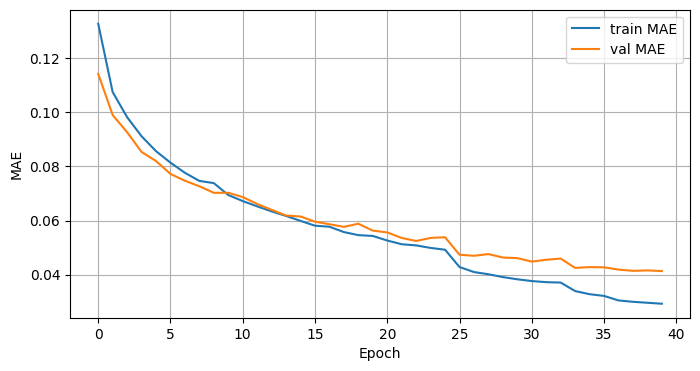

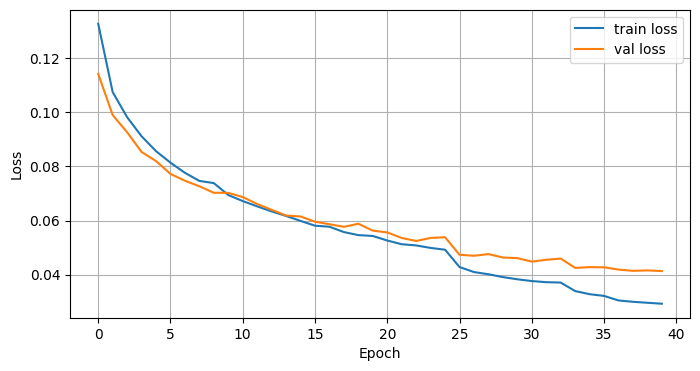

In [ ]:
# =========================
# 9. Training curves
# =========================

if history is None:
    print('Training skipped: weights were loaded with gdown.')
else:
    plt.figure(figsize=(8, 4))
    plt.plot(history.history.get('mae', []), label='train MAE')
    plt.plot(history.history.get('val_mae', []), label='val MAE')
    plt.grid(True)
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history.history.get('loss', []), label='train loss')
    plt.plot(history.history.get('val_loss', []), label='val loss')
    plt.grid(True)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


## 10. Test evaluation

Final evaluation on the held-out test set. As required, both the **mean MAE and its standard deviation** over the test samples are reported. The model reaches a test **MAE ≈ 0.042** (std ≈ 0.046), a large improvement over the ≈ 0.18 baseline, showing that the images are reconstructed far better than the non-informative reference.

In [ ]:
# =========================
# 10. Test MAE mean and standard deviation
# =========================

if os.path.exists(BEST_WEIGHTS_PATH):
    model.load_weights(BEST_WEIGHTS_PATH)
    print('Loaded best weights:', BEST_WEIGHTS_PATH)


def evaluate_model_mae(model, generator):
    values = []
    for i in range(len(generator)):
        x, y = generator[i]
        pred = model.predict(x, verbose=0)
        values.extend(np.mean(np.abs(pred - y), axis=(1, 2, 3)))

    values = np.array(values)
    print('Test MAE mean:', values.mean())
    print('Test MAE std:', values.std())
    return values


test_mae_values = evaluate_model_mae(model, test_generator)

if FAST_DEBUG:
    print('\nFAST_DEBUG=True: these are not final task results.')
    print('Set FAST_DEBUG=False and rerun for the real training.')


Loaded best weights: /content/drive/MyDrive/jigsaw_patch_reconstruction_attention/best_jigsaw_idea1.weights.h5
Test MAE mean: 0.04178214
Test MAE std: 0.045981515


## 11. Reconstruction examples

Qualitative results on a few test samples. For each one, the following are shown side by side: the **scrambled input** patches, the model's **reconstruction**, the **ground-truth** image, and the **per-pixel MAE error map** (brighter = larger error). The error tends to concentrate along the patch borders, which is expected since that is exactly the information removed by erosion and the hardest part to recover.

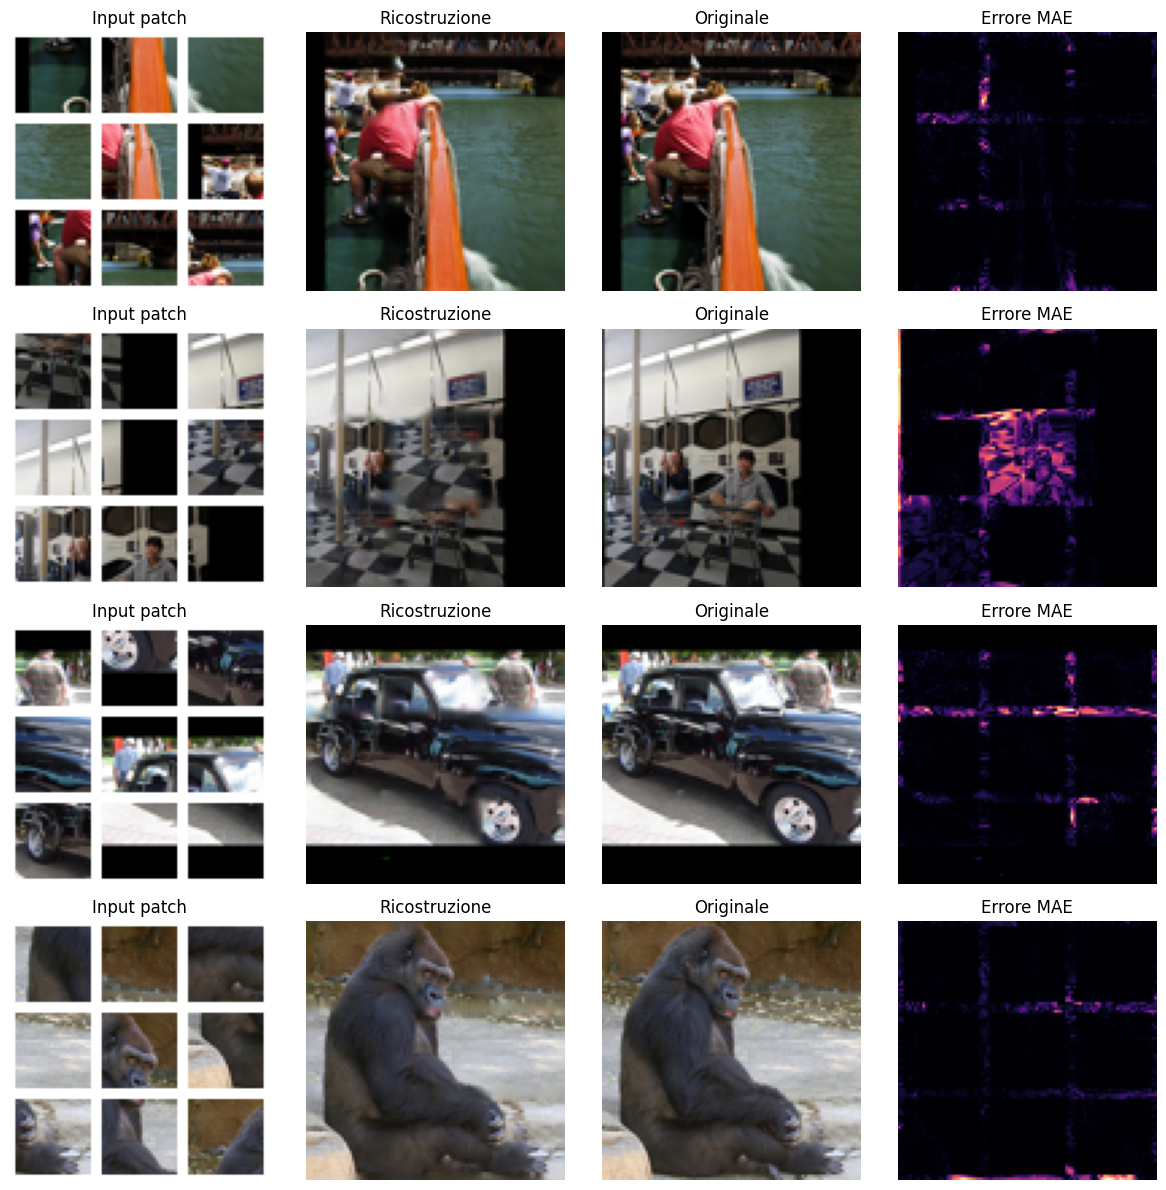

In [ ]:
# =========================
# 11. Visualize reconstructions
# =========================

def show_predictions(model, generator, batch_index=0, n=4):
    x, y = generator[batch_index]
    pred = model.predict(x, verbose=0)
    n = min(n, x.shape[0])

    fig, ax = plt.subplots(n, 4, figsize=(12, 3 * n))
    if n == 1:
        ax = ax[None, :]

    for i in range(n):
        err = np.mean(np.abs(pred[i] - y[i]), axis=-1)

        ax[i, 0].imshow(scrambled_canvas(x[i]))
        ax[i, 0].set_title('Input patch')
        ax[i, 0].axis('off')

        ax[i, 1].imshow(np.clip(pred[i], 0, 1))
        ax[i, 1].set_title('Ricostruzione')
        ax[i, 1].axis('off')

        ax[i, 2].imshow(y[i])
        ax[i, 2].set_title('Originale')
        ax[i, 2].axis('off')

        ax[i, 3].imshow(err, cmap='magma')
        ax[i, 3].set_title('Errore MAE')
        ax[i, 3].axis('off')

    plt.tight_layout()
    plt.show()


show_predictions(model, test_generator, batch_index=0, n=4)


## 12. Weight download verification (gdown)

This cell verifies the submission requirement that the trained weights are downloadable and loadable. It is **self-contained**: the weights are downloaded from Google Drive via `gdown`, the model architecture is rebuilt from scratch, and the weights are loaded into it. A successful run (the message *"weights downloaded via gdown and loaded successfully"*) confirms both that the public link works and that the weights are compatible with the model definition.

In [ ]:
# =========================
# 12. Weight download verification (gdown)
# =========================
!pip -q install gdown
import gdown

url = 'https://drive.google.com/uc?id=13Ge6MB-6Gbe5k3zDZOLSsB878sHmrUhS'
gdown.download(url, '/content/verify_weights.weights.h5', quiet=False)

verify_model = build_model()
verify_model.load_weights('/content/verify_weights.weights.h5')
print('OK: weights downloaded via gdown and loaded successfully.')

Downloading...
From: https://drive.google.com/uc?id=13Ge6MB-6Gbe5k3zDZOLSsB878sHmrUhS
To: /content/verify_weights.weights.h5
100%|██████████| 39.4M/39.4M [00:00<00:00, 206MB/s] 


OK: weights downloaded via gdown and loaded successfully.
